# Oppgave 3
Definerer simulasjon for alternerende potensialer

In [2]:
#Importerer nødvendige biblioteker
import numpy as np
import matplotlib.pyplot as plt
import scipy
import random
import math

#Setter opp plotteparametere
plt.rcParams['figure.figsize'] = [12, 8]  # Width, Height in inches


# Sannsynlighetstettheter for steg til høyre, venstre og ingen steg.
def p_plus(x, V):
    x_clipped = np.clip(x, None, 5000)
    return 1/(1+np.exp(-beta*(V(x_clipped-h)-V(x_clipped+h))) + np.exp(-beta*(V(x_clipped)-V(x_clipped+h))))

def p_null(x, V):
    x_clipped = np.clip(x, None, 5000)
    return 1/(1+np.exp(-beta*(V(x_clipped-h)-V(x_clipped))) + np.exp(-beta*(V(x_clipped+h)-V(x_clipped))))

def p_minus(x, V):
    x_clipped = np.clip(x, None, 5000)
    return 1/(1+np.exp(-beta*(V(x_clipped+h)-V(x_clipped-h))) + np.exp(-beta*(V(x_clipped)-V(x_clipped-h))))

beta = 1000                     # Beta parameteren for at potensialet skal dominere sannsynlighetstettetene
delta_t = 1                     # Tidssteg lengde
h = 1                           # Steg lengde
timeCycle = 75                  # Antall tidssykluser, med 2 tidsperioder i hver
number_of_particles = 3         # Antall partikler
N_x = 100                       # Lengde på perioden til potensialet
T_p = 200                       # Antall tidssteg i en tidssyklus
k_even = 1                      # Konstant for det konstante potensialet, bestemmer styrke
k_odd = 1                       # Konstant for sagtann potensialet, bestemmer styrke
alpha = 0.1                     # Parameter for sagtann potensialet, bestemmer posisjon til maksimum
bin_size = int(2* np.cbrt(N_x)) # Antall bins i histogrammet

# Konstant potensial
def V_even(x, alpha):
    return k_even

# Sagtann potensial
def V_odd(x, alpha):
    x_mod = x % N_x
    if x_mod < alpha * N_x:
        return k_odd * x_mod / (alpha*N_x)
    else:
        return k_odd * (N_x - x_mod) / ((1 - alpha)*N_x)


# Funksjon for random walk simulasjon i alternerende potensial
# Tar inn lenge på tidsperiode, avstand mellom potensial brønner, startposisjone til partiklene og parameteren alpha
def sim2(T_p, N_x, x_start, alpha):

    x = np.zeros((2*timeCycle, number_of_particles)) # 2D-Array med x-posisjoner for hver partikkel. Følger periodiske betingelser ved Nx og -Nx.
    x[0] = x_start
    X = x.copy() # Array med posisjonene til partiklene uten at de looper rundt. "Absolutt posisjon"
    X_cycle = np.zeros((timeCycle, number_of_particles)) # Array for å lagre posisjonene til partiklene i slutten av hver tidssyklus
    J = np.zeros(2*timeCycle*T_p) # Array for å lagre bevegelsesstrømmen

    for k in range(0, 2*timeCycle, delta_t):
        if k % 2 == 0:  # Skifter potensial etter hver tidsperiode for å eksitere / relaksere partikler.
            V = lambda x: V_even(x, alpha)
        else:
            V = lambda x: V_odd(x, alpha)

        for i in range(0, T_p, delta_t):
            previous_X = np.zeros(number_of_particles)
            
            for j in range(number_of_particles):
                a = random.uniform(0, 1) # Trekker fra std norm fordeling og flytter partikkel tilsvarende
                previous_X[j] = X[k][j]

                if a <= p_minus(x[k][j], V):
                    x[k][j] -= h
                elif (1 - p_plus(x[k][j], V)) < a:
                    x[k][j] += h

                if (1 - p_plus(X[k][j], V)) < a:
                    X[k][j] += h 
                elif a <= p_minus(X[k][j], V):
                    X[k][j] -= h 

                if x[k][j]  == -N_x -h:
                    x[k][j] = N_x
                elif x[k][j] == N_x + h:
                    x[k][j] = -N_x

                if j == number_of_particles - 1:
                    J[T_p*k+i] = np.mean(X[k] - previous_X)

                if i == T_p - delta_t and k != 2*timeCycle - delta_t:
                    x[k+1][j] = x[k][j]
                    X[k+1][j] = X[k][j]
                    
    #Finner gjennomsnittlig bevegelsesstrøm for hver tidssyklus                    
    J_avg = np.zeros(timeCycle)
    for i in range(timeCycle):
        J_avg[i] = np.mean(J[i*2*T_p:(i+1)*2*T_p])

    for i in range(timeCycle):
        for j in range(number_of_particles):
            X_cycle[i, j] = X[2*i+1][j]

    return x, X, X_cycle, J, J_avg


# a)

Her kan man se at partiklene beveger seg i en retning, siden de sprer seg i det konstante potensialet
og blir dyttet til neste sagtann brønn i sagtann potensialet(hvis de har kommet seg nok til høyre)


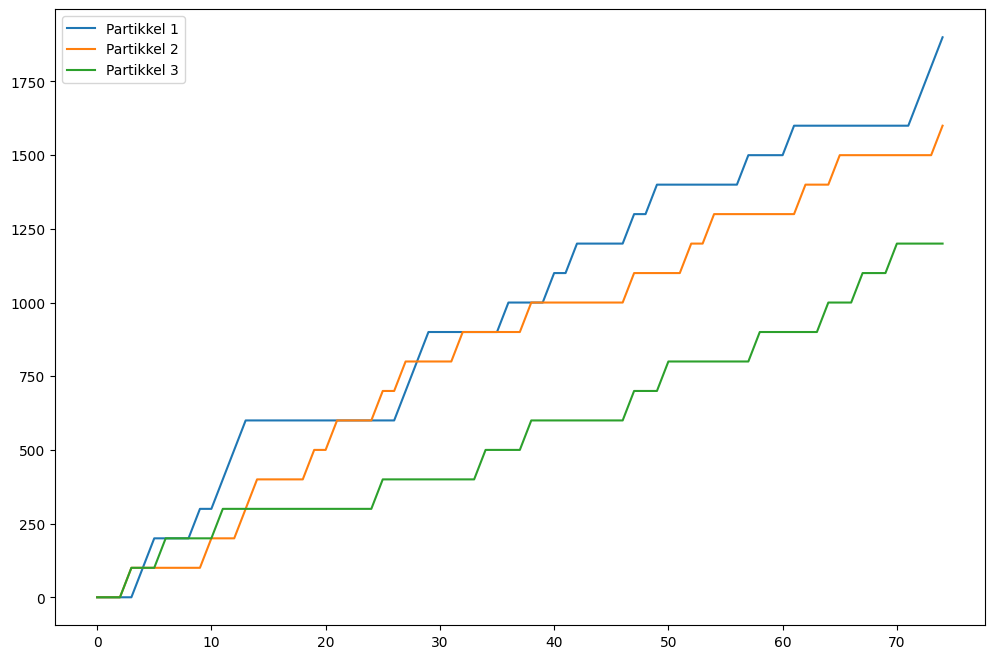

In [14]:
timeCycle = 75          # 75 tidssykluser med 2 Tp i hver syklus
number_of_particles = 3 # Antall partikler
alpha = 0.1             # Parameter for sagtann potensialet
T_p = 200               # Antall tidssteg per tidssyklus
N_x = 100               # Lengden av perioden til potensialet
h = 1                   # Lengden av stegene
delta_t = 1             # Lengden av tidsstegene
beta = 1000             # Beta parameteren for at potensialet skal dominere sannsynlighetstettetene

x_start =  np.zeros(number_of_particles) # Array med alle partikklene i posisjon x=0, iterer gjennom partikler og tidssteg

# Kjører simuleringen og plotter bevegelsesstrømmen
x1, X1, X_cycle1, J1, J_avg1 = sim2(T_p, N_x, x_start, alpha)
for i in range(number_of_particles):
    plt.plot(X_cycle1[:, i], label=f"Partikkel {i+1}")
plt.title("Absolutt posisjon X til partikler i skiftende potensial, alpha = 0.1, beta = 1000")
plt.grid()
plt.xlabel("Tidssyklus")
plt.ylabel("Absolutt posisjon X")
plt.legend()
plt.show()

Her kan man se at partiklene beveger seg i samme retning siden potensialets topper er forskøvet til venstre. I konstant potensial flytter de seg med lik sannsynlighet mot begge sider, når de da er tilbake i sagtann potensialet vil de enten gå tilbake til den dalen de var i før og posisjonen forblir konstant i forhold til siste syklus, eller de vil "dale ned" til neste bunnpunkt til høyre.

# b)

In [ ]:
T_p = 500                       # Antall tidssteg per tidssyklus
N_x = 20                        # Endrer lengden på potensialperioden for at antall partikler ikke skal bli for stort
number_of_particles = 12*N_x    # Med 12*N_x partikler vil det være 6 partikler for hvert heltall mellom -N_x og N_x
timeCycle = 10                  # 10 tidssykluser med 2 potensialperioder i hver
h = 20/100                      # Endrer steglengden for at det skal være likt som om N_x var 100

# Initialiserer 6 partikler i hver posisjon (heltall) mellom -N_x og N_x
integers = range(-N_x, N_x)
x_start = np.array([i for i in integers for _ in range(6)])

x2, X2, X_cycle2, J2, J_avg2 = sim2(T_p, N_x, x_start, 0.8)    # Kjører simulasjonen med de nye startposisjonene

x3, X3, X_cycle3, J3, J_avg3 = sim2(T_p, N_x, x_start, 0.1)    # Kjører simulasjonen med de nye startposisjonene og med alpha = 0.1

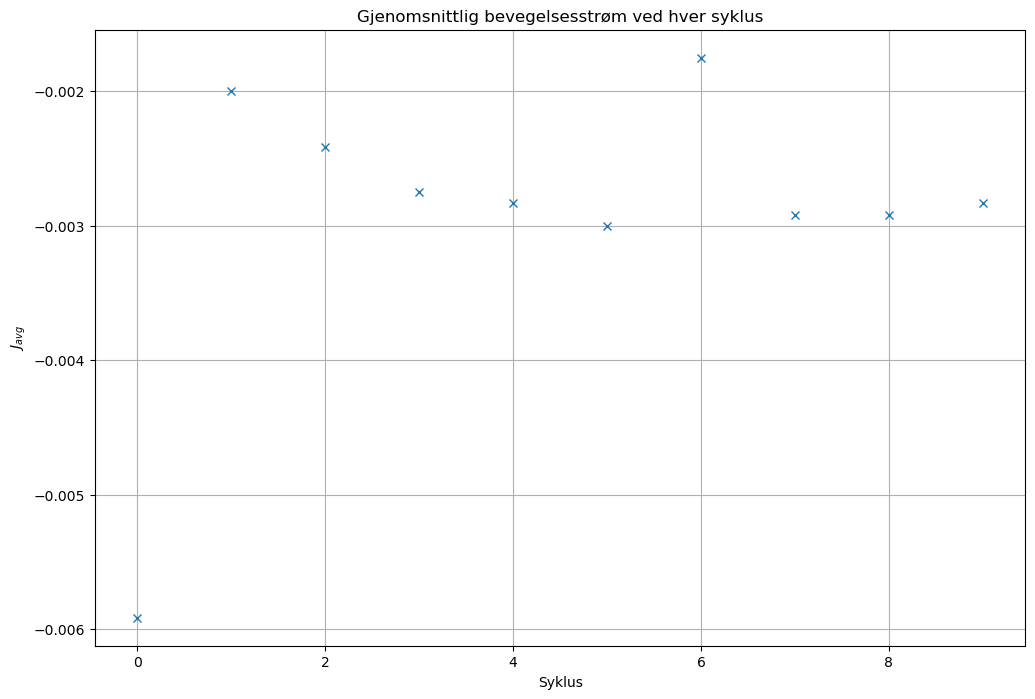


Gjennomsnittlig bevegelsesstrøm per syklus med alpha = 0.8

Syklus 0 : -5.92e-03
-------------------
Syklus 1 : -2.00e-03
-------------------
Syklus 2 : -2.42e-03
-------------------
Syklus 3 : -2.75e-03
-------------------
Syklus 4 : -2.83e-03
-------------------
Syklus 5 : -3.00e-03
-------------------
Syklus 6 : -1.75e-03
-------------------
Syklus 7 : -2.92e-03
-------------------
Syklus 8 : -2.92e-03
-------------------
Syklus 9 : -2.83e-03
-------------------


In [32]:
plt.plot(np.arange(timeCycle), J_avg2, 'x')
plt.title("Gjenomsnittlig bevegelsesstrøm ved hver syklus")
plt.xlabel('Syklus')
plt.ylabel('$J_{avg}$')
plt.grid()
plt.show()

print("\nGjennomsnittlig bevegelsesstrøm per syklus med alpha = 0.8\n")

for i in range(0, len(J_avg2)):
    print(f"Syklus {i} : {J_avg2[i]:.2e}\n-------------------")


Partiklene sprer seg overalt i det konstante potensialet og samler seg så i minima av sagtann potensialet. Det er en gjennomsnittlig negativ strøm gjennom hele simuleringen siden alpha = 0.8. Toppunktene til potensialet er forskjøvet slik at fra et bunnpunkt er toppunktet til venstre nærmest. I det konstante potensialet er det da mer sannsynlig å komme forbi toppunktet til venstre enn det til høyre. Dette gir totalt sett en liten negativ strøm, selv om strøm er null i det konstante potensialet.

In [23]:
print("\nSammenlikning av gjennomsnittlig bevegelsesstrøm i syklus n>0 med bevegelsesstrøm i syklus n=0:")
print("\n")
for i in range(1, len(J_avg2)):
    print(f"Syklus {i} : {(J_avg2[i]-J_avg2[0]):.2e}\n-------------------")


Sammenlikning av gjennomsnittlig bevegelsesstrøm i syklus n>0 med bevegelsesstrøm i syklus n=0:


Syklus 1 : 3.92e-03
-------------------
Syklus 2 : 3.50e-03
-------------------
Syklus 3 : 3.17e-03
-------------------
Syklus 4 : 3.08e-03
-------------------
Syklus 5 : 2.92e-03
-------------------
Syklus 6 : 4.17e-03
-------------------
Syklus 7 : 3.00e-03
-------------------
Syklus 8 : 3.00e-03
-------------------
Syklus 9 : 3.08e-03
-------------------


Her kan vi legge merke til at differansen er positiv, altså at bevegelsesstrømmen er mer negativ i første syklus enn i alle etterfølgende sykluser. Dette kommer av at partiklene starter jevnt fordelt og dermed vil mange flere være lenger unna bunnpunktene enn om de hadde startet syklusen i dem, slik de gjør i senere sykluser. At alpha = 0.8 gjør ytterligere at partiklene som dras mot en potensialbrønn til venstre i V1 har lenger "reisevei" til den de som dras mot høyre. Dette gir også en mer negativ strøm.

### Gjentar med alpha = 0.1

In [40]:
print("\nGjennomsnittlig bevegelsesstrøm per syklus med alpha = 0.1\n")

for i in range(0, len(J_avg3)):
    print(f"Syklus {i} : {J_avg3[i]:.2e}\n-------------------")


Gjennomsnittlig bevegelsesstrøm per syklus med alpha = 0.1

Syklus 0 : 7.92e-03
-------------------
Syklus 1 : 5.83e-03
-------------------
Syklus 2 : 6.25e-03
-------------------
Syklus 3 : 5.75e-03
-------------------
Syklus 4 : 6.42e-03
-------------------
Syklus 5 : 5.75e-03
-------------------
Syklus 6 : 5.25e-03
-------------------
Syklus 7 : 5.58e-03
-------------------
Syklus 8 : 5.83e-03
-------------------
Syklus 9 : 5.42e-03
-------------------


In [41]:
print("\nSammenlikning av gjennomsnittlig bevegelsesstrøm i syklus n>0 med bevegelsesstrøm i syklus n=0.\nJ_avg(n)-J_avg(0):")
print("\n")
for i in range(1, len(J_avg3)):
    print(f"Syklus {i} : {(J_avg3[i]-J_avg3[0]):.2e}\n-------------------")


Sammenlikning av gjennomsnittlig bevegelsesstrøm i syklus n>0 med bevegelsesstrøm i syklus n=0.
J_avg(n)-J_avg(0):


Syklus 1 : -2.08e-03
-------------------
Syklus 2 : -1.67e-03
-------------------
Syklus 3 : -2.17e-03
-------------------
Syklus 4 : -1.50e-03
-------------------
Syklus 5 : -2.17e-03
-------------------
Syklus 6 : -2.67e-03
-------------------
Syklus 7 : -2.33e-03
-------------------
Syklus 8 : -2.08e-03
-------------------
Syklus 9 : -2.50e-03
-------------------


Ser igjen at vi nå får en positiv bevegelses strøm. Dette stemmer overens med den tidligere forklaringen. Nå spissene er skiftet mot venstre som gir en bevegelsesstrøm i positiv retning, denne gangen av større magnitude siden alpha er skiftet lenger unna 0.5 enn tidligere. Igjen ser vi at den første bevegelsesstrømmen er desidert størst siden partiklene starter jevnt fordelt.

# c)

In [ ]:
alpha = 0.8                     # Alpha som bestemmer plassering av topper i potensialet
N_x = 10                        # Enderer lengden på potensialperioden for at antall partikler ikke skal bli for stort
number_of_particles = 40*N_x    # Med 40*N_x partikler vil det være 6 partikler for hvert heltall mellom -N_x og N_x
timeCycle = 1                   # 10 tidssykluser med 2 potensialperioder i hver
h = 10/100                      # Endrer steglengden for at det skal være likt som om N_x var 100

integers = np.arange(-N_x, N_x, N_x)
x_start = np.array([i for i in integers for _ in range(int(number_of_particles/2))]) # Plasserer partikler i potensialbrønner

T_p = 1
T_p_array = []

X4_all_Tp = []
J_avg_all_Tp1 = []

# Løkke som simulerer for 50 verdier av Tp
for r in range(50):
    T_p_array.append(T_p) # Lagrer Tp verdien
    x4, X4, X_cycle4, J4, J_avg4 = sim2(T_p, N_x, x_start, alpha) # Kjører simulering med Tp
    X4_all_Tp.append(X_cycle4[0]) # Lagrer absolutt X posisjon
    J_avg_all_Tp1.append(J_avg4[0]) # Lagrer gjennomsnittlig bevegelsesstrøm
    T_p += 10 # Øker Tp før neste iterasjon

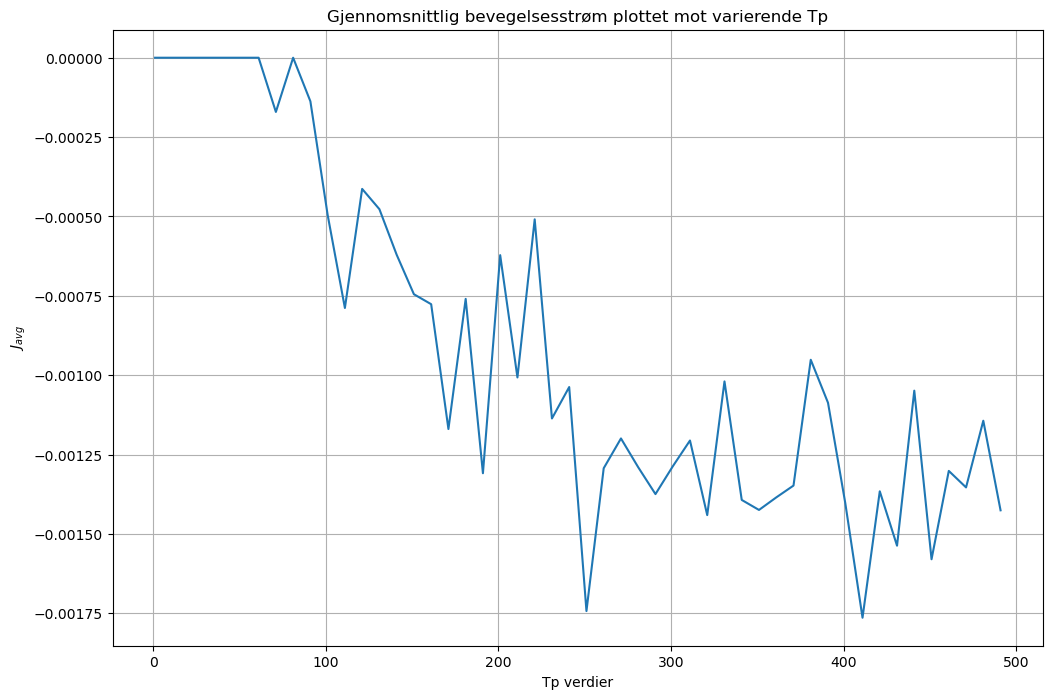

In [36]:
plt.plot(T_p_array, J_avg_all_Tp1)
plt.title('Gjennomsnittlig bevegelsesstrøm plottet mot varierende Tp')
plt.ylabel("$J_{avg}$")
plt.xlabel('Tp verdier')
plt.grid()
plt.show()

Vi ser at for større Tp blir gjennomsnittlig bevegelsesstrøm mer og mer negativ, spesielt i Tp intervallet 100-250. Dette kommer av at når Tp er liten er det ikke nok tid for partiklene å bevege seg forbi nærmeste potensial topp mens de er i det konstante potensialet. Jo flere tidssteg de beveger seg i det konstante potensialet, jo større sannsynlighet for at noen av dem har rukket å bevege seg mot neste brønn. Etterhvert er det nok tidssteg til at dette stabiliserer seg og økning av tidssteg ikke lenger endrer partikkelstrømmen betydelig.

# d)

In [82]:
T_p = 500                       # Endrer alpha for å se om det påvirker bevegelsesstrømmen
N_x = 10                        # Enderer lengden på potensialperioden for at antall partikler ikke skal bli for stort
number_of_particles = 4*N_x     # Med 12*N_x partikler vil det være 6 partikler for hvert heltall mellom -N_x og N_x
timeCycle = 1                   # 10 tidssykluser med 2 potensialperioder i hver
h = 10/100                      # Endrer steglengden for at det skal være likt som om N_x var 100

integers = np.arange(-N_x, N_x, N_x)
x_start = np.array([i for i in integers for _ in range(int(number_of_particles/2))])

alpha = 0
alpha_array = []

X4_all_alpha = []
J_avg_all_alpha = []

# Løkke som simulerer for 50 verdier av alpha
for r in range(50):
    alpha_array.append(alpha) # Lagrer alpha verdi
    x4, X4, X_cycle4, J4, J_avg4 = sim2(T_p, N_x, x_start, alpha) # Kjører simulasjon
    X4_all_alpha.append(X_cycle4[0]) # Lagrer absolutt posisjon
    J_avg_all_alpha.append(J_avg4[0]) # Lagrer gjennomsnittsstrøm
    alpha += 0.02 # Øker alpha før neste iterasjon

C:\Users\Trond\AppData\Local\Temp\ipykernel_13224\2518503808.py:15: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-beta*(V(x_clipped-h)-V(x_clipped+h))) + np.exp(-beta*(V(x_clipped)-V(x_clipped+h))))
C:\Users\Trond\AppData\Local\Temp\ipykernel_13224\2518503808.py:23: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-beta*(V(x_clipped+h)-V(x_clipped-h))) + np.exp(-beta*(V(x_clipped)-V(x_clipped-h))))


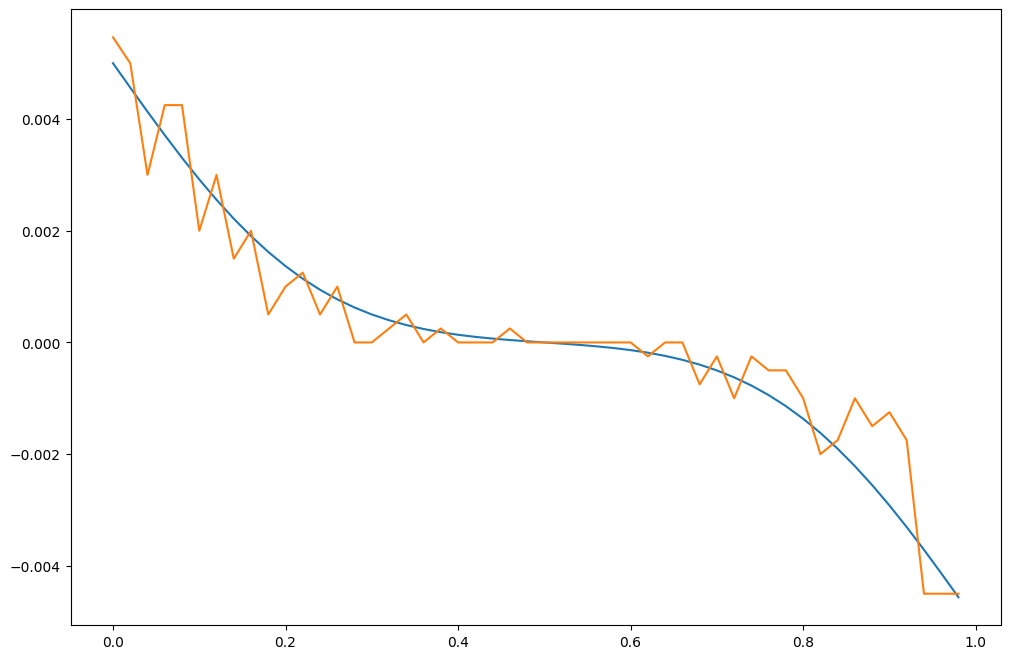

In [83]:
plt.plot(alpha_array, J_avg_all_alpha)
plt.title('Gjenommsnittlig bevegelsesstrøm plottet mot varierende Tp')
plt.ylabel("α")
plt.xlabel('Tp verdier')
plt.grid()
plt.show()

Parameteren alpha forskyver hvor på x-aksen toppene til sagtannpotensialet befinner seg. Vi observerer her at små alpha gir strøm i positiv retning og store alpha gir stadig mer strøm i negativ retning, med en strømning som stabiliserer seg rundt 0 ved alpha = 0.5. Partiklene, når de er i det konstante potensial, sprer seg utover fra sitt startpunkt. Deretter bestemmes forflyttelsen av hvor de har havnet i forhold til topp- og bunnpunkt til sagtannpotensialet, og de beveger seg mot lavere energinivåer i dalene de befinner seg i. Dette impliserer at når bunnpunktet partikkelen var i har et toppunkt i nærheten til høyre vil den med større sannsynlighet kunne "komme forbi" denne toppen i V2 og dermed dale enda lenger til høyre i V1 tidsrommet, enn å kunne komme forbi toppunktet til venstre. En netto gjennomsnittlig strøm mot høyre oppstår i syklusen. Det motsatt skjer når alpha er stor. Når alpha = 0.5 er disse sannsynlighetene like, og dette gir gjennomsnittlig strøm 0. 